# Neural Networks — Practice 2
## Train, Calibrate & Evaluate Your Network
### Master in Economics · Neural Networks Module

---

**Building on Practice 1**, this session we will:
- Diagnose overfitting by analyzing training curves
- Apply **Dropout** and **Early Stopping** to regularize our model
- Use **L2 regularization** to penalize large weights
- Tune hyperparameters systematically
- Do a full final evaluation with all metrics
- *(Bonus)** Get a first taste of **PyTorch**

**Time:** ~2 hours

Run cells with `Shift + Enter`. Always change **one thing at a time** when experimenting.


## 0. Setup — Same as Practice 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print("Setup complete. TF version:", tf.__version__)


Setup complete. TF version: 2.19.0


## 1. Reload Data from Practice 1

In [ ]:
# Load and preprocess (same as Practice 1 — all in one block)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)
df = df.rename(columns={'default payment next month': 'default'})

X = df.drop(['ID', 'default'], axis=1).values
y = df['default'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,  X_test,  y_val,  y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")


Train: 21,000 | Val: 4,500 | Test: 4,500


## 2. Rebuild Baseline & Diagnose

### 2.1 Baseline model (from Practice 1)

In [ ]:
# Rebuild baseline model — train for MORE epochs to expose overfitting
def build_baseline():
    m = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(23,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return m

model_baseline = build_baseline()

history_baseline = model_baseline.fit(
    X_train, y_train,
    epochs=100,           # More epochs to reveal overfitting
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=0
)
print("Baseline trained!")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline trained!


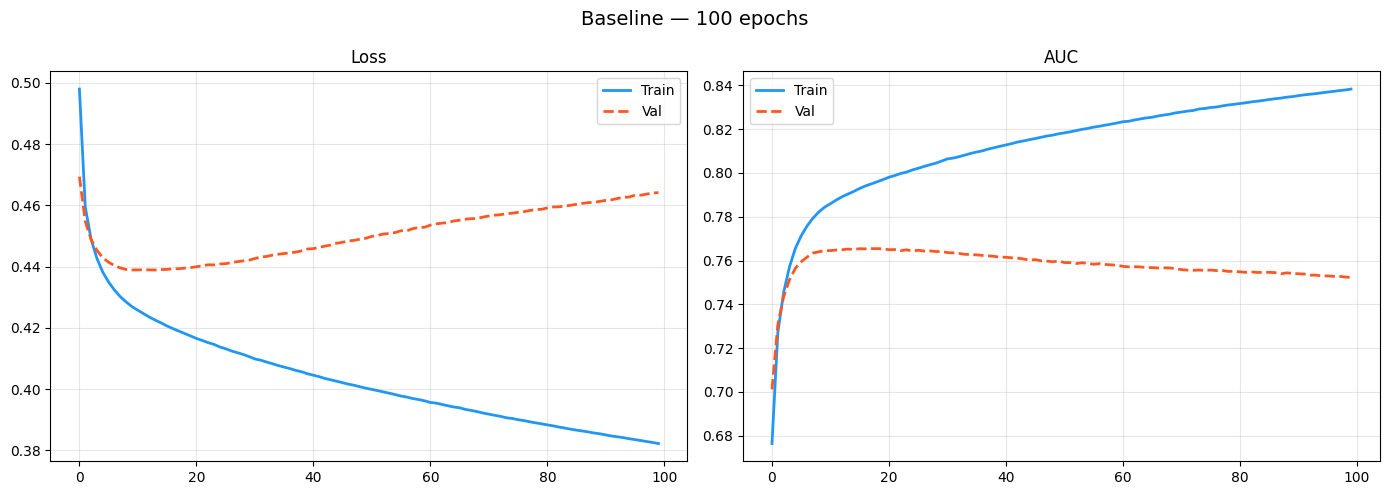

In [ ]:
# Plot helper (we'll reuse this throughout)
def plot_history(history, title='Training Curves', baseline_history=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, key, label in [(axes[0], 'loss', 'Loss'), (axes[1], 'auc', 'AUC')]:
        ax.plot(history.history[key],         label='Train', lw=2, color='#2196F3')
        ax.plot(history.history[f'val_{key}'],label='Val',   lw=2, color='#FF5722', ls='--')
        if baseline_history:
            ax.plot(baseline_history.history[f'val_{key}'], label='Baseline val', lw=1.5, color='gray', ls=':')
        ax.set_title(label); ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

plot_history(history_baseline, 'Baseline — 100 epochs')


### Question 2.1 — Diagnose the baseline
> **Look at the curves carefully:**
> 1. At what epoch do train and validation loss start to diverge?
> 2. Does this model overfit? What's the evidence?
> 3. What would be the best stopping point if we could go back in time?

**Answer:**
* The train and validation loss start to diverge very early, around epoch 3 -5, once the validation loss bottoms out and then begins to rise while train loss keeps decreasing.
* Yes, there is overfitting in the model. After the first few epochs, training loss continues to steadily decrease while validation loss slowly increases and validation AUC first plateaus and then declines. This shows that the model is fitting noise in the training set rather than improving generalization.
* The best stopping point would be close to the minimum validation loss / maximum validation AUC, which occurs around epoch 10 (or slightly before).

---
## 3. Early Stopping

**Early Stopping** monitors a metric during training and automatically stops when it stops improving.
This avoids both overfitting AND wasted computation.


#### Your turn! Add Early Stopping

Stopped at epoch: 200
Best val AUC: 0.7664


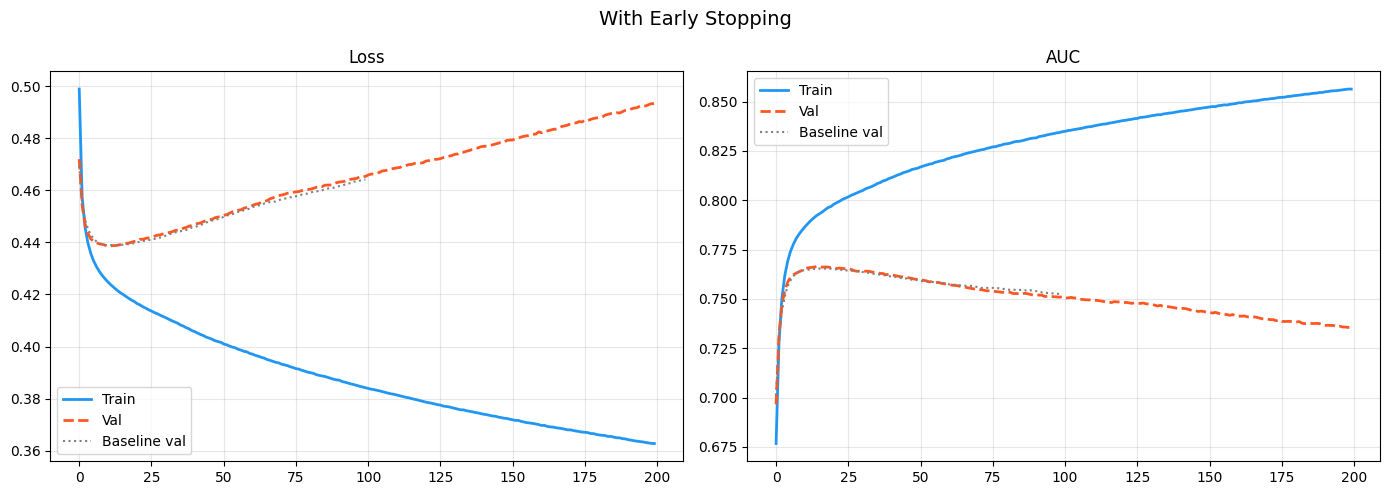

In [ ]:
# Create the EarlyStopping callback
early_stop = EarlyStopping(
    monitor='auc',       # ← what metric to monitor? (hint: we want to stop when validation gets worse)
    patience=10,        # ← how many epochs to wait before stopping? (try 10–15)
    restore_best_weights=True,   # ← go back to the best checkpoint!
)

model_es = build_baseline()

history_es = model_es.fit(
    X_train, y_train,
    epochs=200,          # Set high — early stopping will stop us before this
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

print(f"Stopped at epoch: {len(history_es.history['loss'])}")
print(f"Best val AUC: {max(history_es.history['val_auc']):.4f}")
plot_history(history_es, 'With Early Stopping', history_baseline)


---
## 4. Dropout

**Dropout** randomly zeros out a fraction of neurons at each training step.
This forces the network to learn **redundant representations** and prevents any single neuron from becoming too important.

Dropout is only active during training — at inference, all neurons are used (but scaled).


#### Your turn! Build a model with Dropout

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Dropout model — Test AUC: 0.7761
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Baseline      — Test AUC: 0.7535


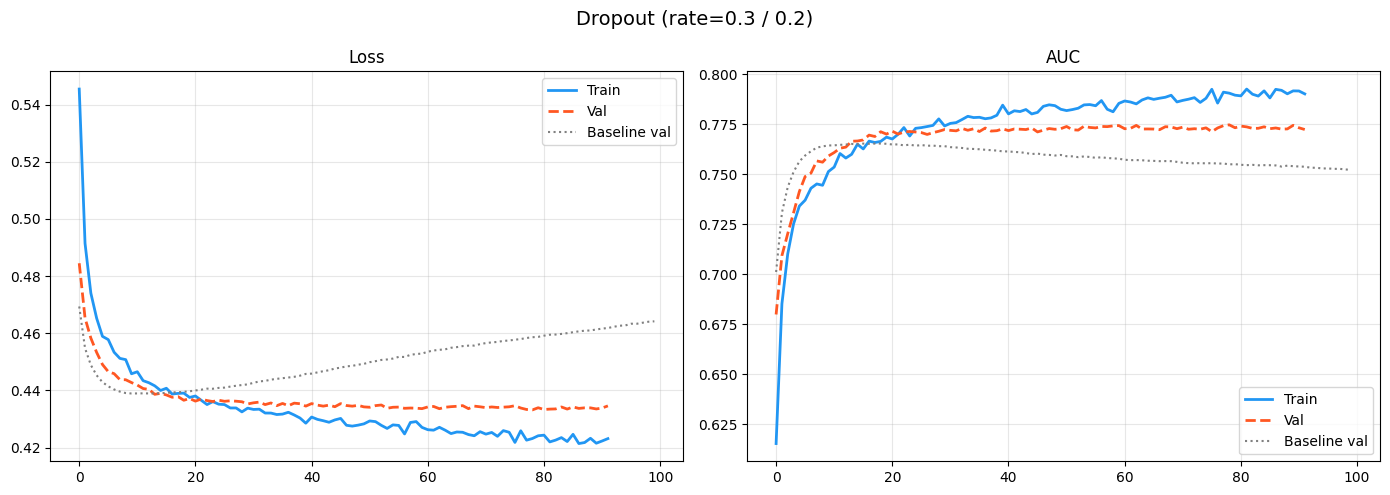

In [ ]:
# Build a model with Dropout layers
# Dropout(rate) → 'rate' fraction of neurons are randomly dropped each step
# Common values: 0.1 to 0.5 — start with 0.2–0.3

model_dropout = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(23,)),
    layers.Dropout(.3),      # ← Choose dropout rate for this layer (e.g. 0.3)

    layers.Dense(32, activation='relu'),
    layers.Dropout(.2),      # ← Choose dropout rate for this layer (e.g. 0.2)

    layers.Dense(1, activation='sigmoid')
])

model_dropout.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=['accuracy', keras.metrics.AUC(name='auc')])

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=200,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

auc_dropout = roc_auc_score(y_test, model_dropout.predict(X_test).flatten())
print(f"Dropout model — Test AUC: {auc_dropout:.4f}")
print(f"Baseline      — Test AUC: {roc_auc_score(y_test, model_baseline.predict(X_test).flatten()):.4f}")
plot_history(history_dropout, f'Dropout (rate={model_dropout.layers[1].rate:.1f} / {model_dropout.layers[3].rate:.1f})', history_baseline)


### Question 4.1 — Understanding Dropout
> 1. **How does the training curve look with Dropout compared to the baseline?**
>    (Hint: is the train/val gap smaller? Is training noisier?)
> 2. **Why does Dropout make training noisier?**
> 3. **Why do we NOT use Dropout at inference time?**

**Answer:**

* Train/val gap is much smaller with dropout. Training is also noisier because there are a lot of small fluctuations in the curve.
* Dropout makes training noisier because here, the model can't rely on any single neuron, so weights fluctuate more between updates. It regularises by stopping the co-adaption of neurons.
* We don't use Dropout at inference time because: a) we want consistent, reproducible predictions and randomly dropping neurons would not allow for this to happen; b) we want all neurons active to use the model's full learned representation and so as compensation for the extra active neurons, weights are scaled by the dropout rate. Which means that the training activations are scaled up.

---
## 5. L2 Regularization

**L2 regularization** adds a penalty to the loss function:

```
New Loss = Original Loss + λ · Σ wᵢ²
```

This penalizes large weights, encouraging the model to spread information more evenly.
`λ` (lambda) controls the strength of regularization: too high → underfitting; too low → no effect.


#### Your turn! Add L2 regularization

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
L2 model  — Test AUC: 0.7696


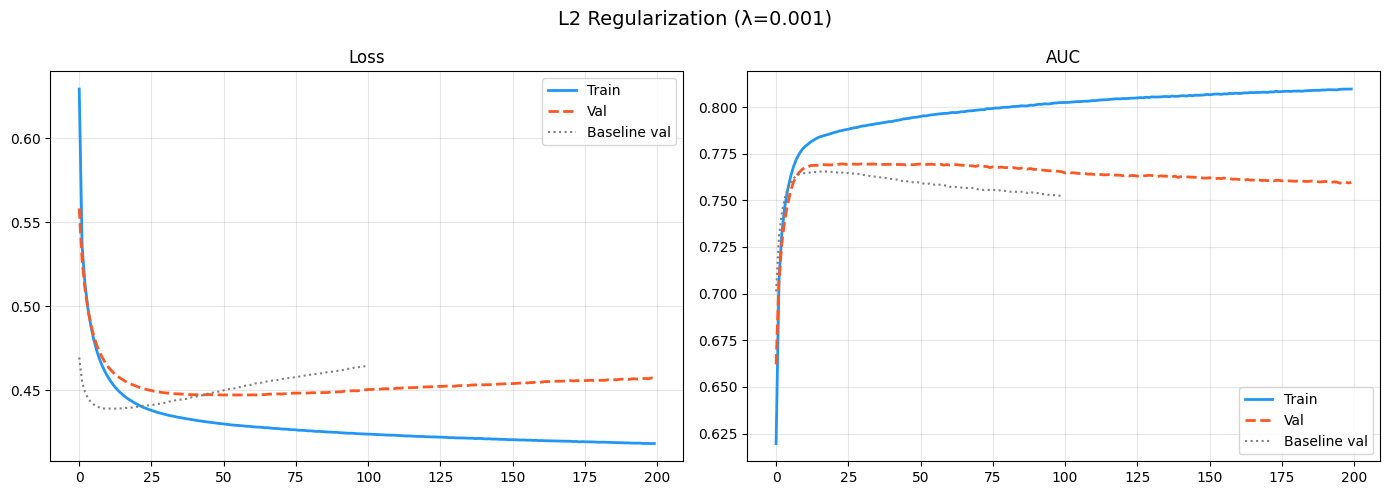

In [ ]:
# Build a model with L2 weight regularization
# λ = 0.001 is a good starting point

model_l2 = keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),   # ← choose λ (try 0.001)
                 input_shape=(23,)),

    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),  # ← same λ

    layers.Dense(1, activation='sigmoid')
])

model_l2.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', keras.metrics.AUC(name='auc')])

history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=200,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

auc_l2 = roc_auc_score(y_test, model_l2.predict(X_test).flatten())
print(f"L2 model  — Test AUC: {auc_l2:.4f}")
plot_history(history_l2, f'L2 Regularization (λ=0.001)', history_baseline)


---
## 6. Combine Everything — Best Model

Now let's put it all together: Dropout + L2 + Early Stopping in one model.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
🏆 Best model — Test AUC: 0.7752


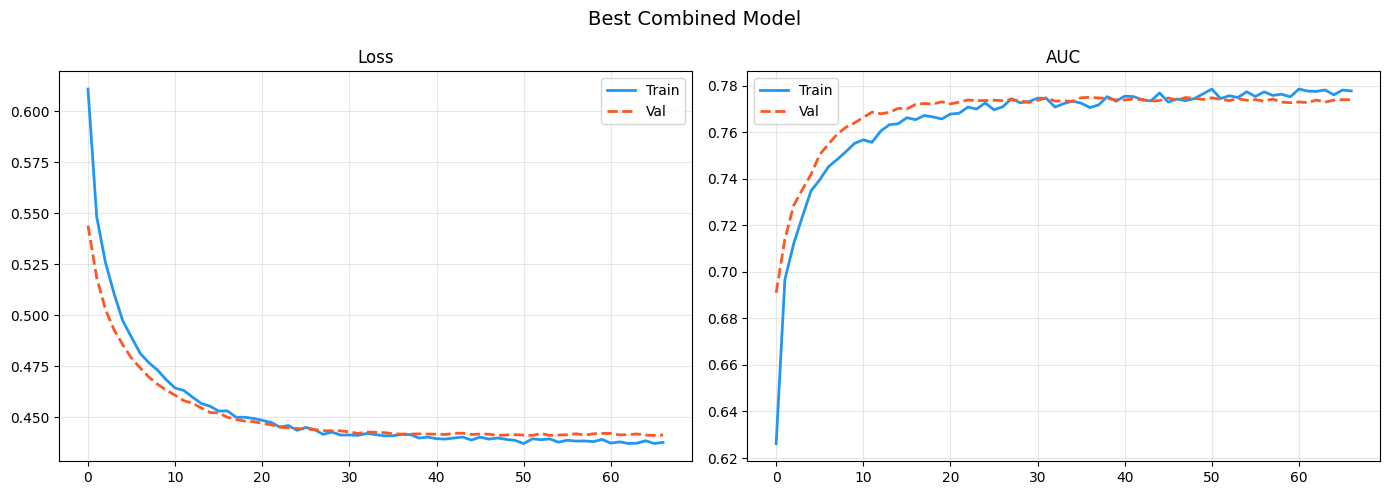

In [ ]:
# Design your best model — combine regularization techniques
model_best = keras.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(23,)),
    layers.Dropout(.3),

    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(.2),

    layers.Dense(1, activation='sigmoid')
])

model_best.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy', keras.metrics.AUC(name='auc')])

# Use early stopping with patience=15
best_es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_best = model_best.fit(
    X_train, y_train,
    epochs=300,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[best_es],
    verbose=0
)

auc_best = roc_auc_score(y_test, model_best.predict(X_test).flatten())
print(f"🏆 Best model — Test AUC: {auc_best:.4f}")
plot_history(history_best, 'Best Combined Model')


---
## 7. Full Final Evaluation

Now that we've chosen our best model, let's do a thorough evaluation on the **test set**.


In [ ]:
# Final predictions
y_prob_best = model_best.predict(X_test).flatten()
y_pred_best = (y_prob_best >= 0.5).astype(int)

# All metrics
auc_final = roc_auc_score(y_test, y_prob_best)

print("=" * 55)
print(f"  FINAL MODEL — TEST SET EVALUATION")
print("=" * 55)
print(f"  AUC-ROC:  {auc_final:.4f}")
print("=" * 55)
print()
print(classification_report(y_test, y_pred_best, target_names=['No Default', 'Default']))


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  FINAL MODEL — TEST SET EVALUATION
  AUC-ROC:  0.7752

              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      3504
     Default       0.66      0.35      0.45       996

    accuracy                           0.82      4500
   macro avg       0.75      0.65      0.67      4500
weighted avg       0.80      0.82      0.79      4500



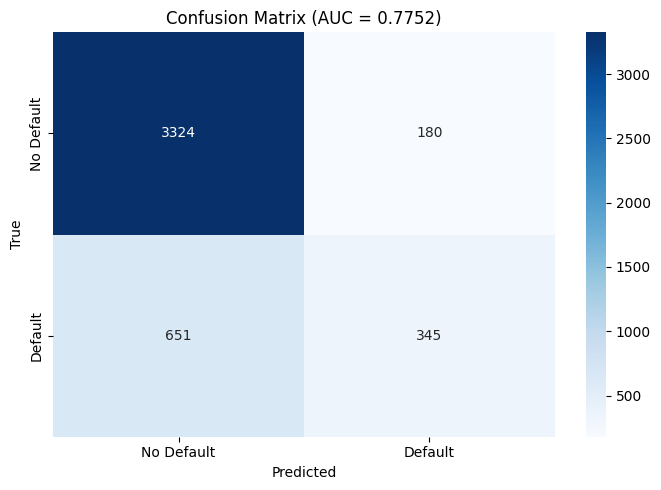

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title(f'Confusion Matrix (AUC = {auc_final:.4f})')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


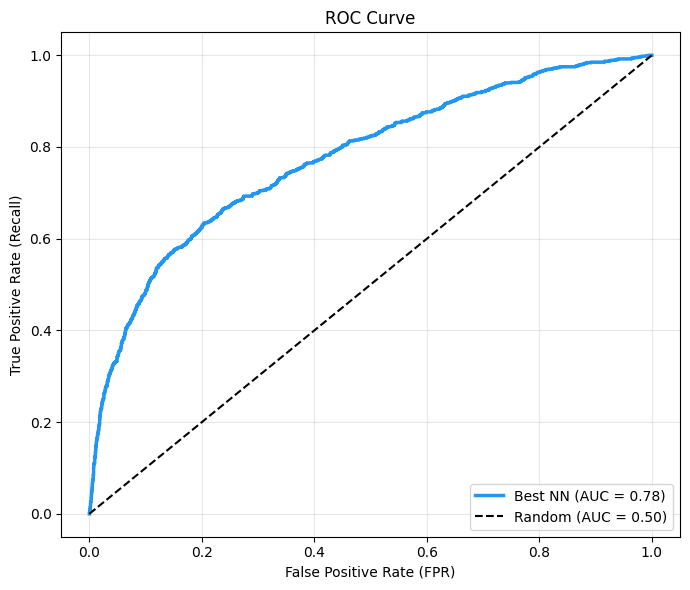

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2.5, color='#2196F3', label=f'Best NN (AUC = {auc_final:.2f})')
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Question 7.1 — Business interpretation
> Imagine you are a bank risk analyst presenting this model to management.
>
> 1. **What does a False Negative mean in this context?** Is it costly?
> 2. **The model has Recall ≈ 0.45 on defaults.** In plain English: what does this mean?
> 3. **Would you lower the decision threshold from 0.5 to 0.3?** What would be the trade-off?

**Answer:**
* FN means that there are Defaults when the model predicted Not Default. It is very costly for the bank because this means that that the bank should've rejected a loan that it approved and the client defaulted. This causes the bank to lose money.
*  My model reports Recall = .35 which means that the model correctly identifies only 35% of actual defaulters.
* Reducing the decision threshold would mean that the bank would be able to catch more true defaulters but it is also possible that the good clients get wrongly rejected by the model. Those who won't default are predicted as defaulters by the model. So basically, the main trade off is: Either banks miss out on customers who won't default or they make a loss by lending to customers who will default.

### 8. Threshold Tuning

In [ ]:
# ✏️ Compare different decision thresholds
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = [0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7]
rows = []
for t in thresholds:
    yp = (y_prob_best >= t).astype(int)
    if yp.sum() == 0:
        continue
    rows.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, yp), 3),
        'Recall':    round(recall_score(y_test, yp), 3),
        'F1':        round(f1_score(y_test, yp), 3),
        'Defaults predicted': yp.sum()
    })

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False))
print()
print("Which threshold would you choose if Recall > 0.60 is required?")


 Threshold  Precision  Recall    F1  Defaults predicted
      0.20      0.469   0.635 0.539                1347
      0.30      0.561   0.535 0.548                 950
      0.35      0.590   0.475 0.526                 802
      0.40      0.615   0.426 0.503                 689
      0.45      0.637   0.394 0.487                 615
      0.50      0.657   0.346 0.454                 525
      0.60      0.716   0.289 0.412                 402
      0.70      0.775   0.069 0.127                  89

Which threshold would you choose if Recall > 0.60 is required?


### Question 8.1
> **Look at the threshold table.**
> - Which threshold maximizes F1?
> - Which threshold gives Recall > 0.60?
> - What's the Precision penalty for that higher Recall?

**Answer:**
* 0.3 maximises F1
* 0.2 gives recall greater than 0.6
* Comparing the 0.2 and 0.3 thresholds, we can see that the precision changes from 0.469 to 0.561 (least precision and most recall).

---
## Bonus: First Steps with PyTorch

*If you've finished the main exercises and want to go further...*

PyTorch is the framework most used in academic research and is increasingly popular in industry.
The syntax is more explicit than Keras — but this gives you much more control and flexibility.

We'll rebuild a simplified version of our credit default model in PyTorch to see the differences.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Use GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


In [ ]:
# Convert numpy arrays to PyTorch tensors
# PyTorch works with torch.Tensor, not numpy arrays
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)   # shape: (N, 1)
X_val_t   = torch.FloatTensor(X_val).to(device)
y_val_t   = torch.FloatTensor(y_val).unsqueeze(1).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)

# Create DataLoaders (handles batching automatically)
train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

print("Tensors created!")
print(f"X_train tensor shape: {X_train_t.shape}")
print(f"y_train tensor shape: {y_train_t.shape}")


Tensors created!
X_train tensor shape: torch.Size([21000, 23])
y_train tensor shape: torch.Size([21000, 1])


In [ ]:
# ─── Define the model ─────────────────────────────────────────────────────────
# In PyTorch: define a class that inherits from nn.Module
# __init__ defines the layers
# forward() defines how data flows through the layers

class CreditDefaultNet(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, dropout_rate):
        super(CreditDefaultNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden1),   # Fully connected layer
            nn.ReLU(),                        # Activation
            nn.Dropout(dropout_rate),         # Regularization

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.7),  # Slightly less dropout in later layer

            nn.Linear(hidden2, 1),
            nn.Sigmoid()                      # Output probability
        )

    def forward(self, x):
        return self.network(x)

# Instantiate the model
pt_model = CreditDefaultNet(
    input_dim=23,
    hidden1=64,
    hidden2=32,
    dropout_rate=0.3
).to(device)

print(pt_model)
print()
total_params = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


CreditDefaultNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.21, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total trainable parameters: 3,649


In [ ]:
# ─── Define optimizer and loss function ───────────────────────────────────────
optimizer = optim.Adam(pt_model.parameters(), lr=0.001)
criterion = nn.BCELoss()    # Binary Cross-Entropy Loss

# ─── Training loop — the explicit version of what Keras .fit() does ───────────
def train_pytorch(model, loader, val_X, val_y, epochs=50):
    train_losses, val_losses, val_aucs = [], [], []

    for epoch in range(epochs):
        model.train()  # ← Training mode (enables Dropout)
        epoch_loss = 0

        for X_batch, y_batch in loader:
            optimizer.zero_grad()          # 1. Clear previous gradients
            preds = model(X_batch)         # 2. Forward pass
            loss  = criterion(preds, y_batch)  # 3. Compute loss
            loss.backward()                # 4. Backward pass (autograd!)
            optimizer.step()               # 5. Update weights
            epoch_loss += loss.item()

        # Evaluate on validation set
        model.eval()  # ← Evaluation mode (disables Dropout)
        with torch.no_grad():  # Don't compute gradients during evaluation
            val_preds = model(val_X).cpu().numpy().flatten()
            val_loss  = criterion(model(val_X), val_y).item()
            val_auc   = roc_auc_score(y_val, val_preds)

        train_losses.append(epoch_loss / len(loader))
        val_losses.append(val_loss)
        val_aucs.append(val_auc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {epoch_loss/len(loader):.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    return train_losses, val_losses, val_aucs

print("Starting PyTorch training...")
train_losses, val_losses, val_aucs = train_pytorch(pt_model, train_loader, X_val_t, y_val_t, epochs=50)


Starting PyTorch training...
Epoch  10 | Train Loss: 0.4467 | Val Loss: 0.4416 | Val AUC: 0.7619
Epoch  20 | Train Loss: 0.4377 | Val Loss: 0.4342 | Val AUC: 0.7749
Epoch  30 | Train Loss: 0.4348 | Val Loss: 0.4335 | Val AUC: 0.7772
Epoch  40 | Train Loss: 0.4317 | Val Loss: 0.4327 | Val AUC: 0.7764
Epoch  50 | Train Loss: 0.4253 | Val Loss: 0.4325 | Val AUC: 0.7764


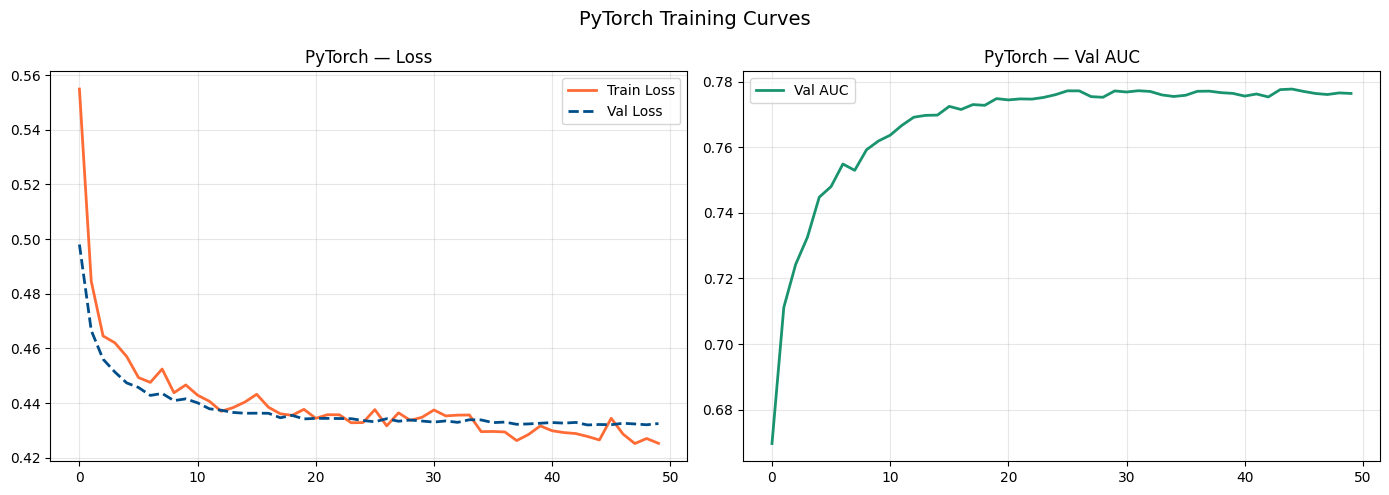


🔥 PyTorch model — Test AUC: 0.7757
   Keras best model — Test AUC: 0.7752


In [ ]:
# Plot PyTorch training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train Loss', lw=2, color='#FF6B35')
axes[0].plot(val_losses,   label='Val Loss',   lw=2, color='#004E89', ls='--')
axes[0].set_title('PyTorch — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(val_aucs, label='Val AUC', lw=2, color='#1A936F')
axes[1].set_title('PyTorch — Val AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('PyTorch Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

# Final test AUC
pt_model.eval()
with torch.no_grad():
    pt_probs = pt_model(X_test_t).cpu().numpy().flatten()
pt_auc = roc_auc_score(y_test, pt_probs)
print(f"\n🔥 PyTorch model — Test AUC: {pt_auc:.4f}")
print(f"   Keras best model — Test AUC: {auc_final:.4f}")


### Bonus Question — Keras vs PyTorch
> 1. **The results should be very similar — the architecture is the same. Why?**
> 2. **The PyTorch training loop is much more verbose than Keras `.fit()`. What's the advantage of writing it explicitly?**
> 3. **Where would you add Early Stopping in the PyTorch loop?** (Think about it — there's no callback system)

**Answer:**
* yes the results for both are very similar. PyTorch is 0.7757 and Keras is 0.7752. they have both identical layer structure, hidden units, and dropout rates. The architecture is the same thats why the results are so similar.
* PyTorch requries more explicitly written instructions which makes it better for research and easy to modify things which are different from the standard. It also gives us full control ovr all aspects of the loop.
* We can add Early Stopping in PyTorch at the end of each epoch but in Keras, it is automatically done


### Key Difference: Keras vs PyTorch

```python
# KERAS: compact, automatic
model.fit(X_train, y_train, epochs=50, callbacks=[early_stop])

# PYTORCH: explicit, full control
for epoch in range(50):
    model.train()
    for X_batch, y_batch in loader:
        optimizer.zero_grad()   # manual gradient reset
        preds = model(X_batch)  # manual forward pass
        loss  = criterion(preds, y_batch)
        loss.backward()         # manual backward pass
        optimizer.step()        # manual weight update
```

**Keras:** Great for fast prototyping, standard architectures, beginners.
**PyTorch:** Better for research, custom architectures, non-standard training loops.

Most academic papers use PyTorch. Most industry production systems use both.


---
## 🏁 Final Summary — Practice 2

| Technique | What it does | When to use |
|---|---|---|
| **Early Stopping** | Stops training before overfitting | Always — it's free! |
| **Dropout** | Randomly drops neurons during training | When you see overfitting |
| **L2 Regularization** | Penalizes large weights | Tabular data with many features |
| **Threshold tuning** | Adjusts decision boundary | When Precision/Recall trade-off matters |

### Challenge Results — Did you beat the targets?
- 🥉 Bronze: AUC > 0.75 ✓ / ✗
- 🥈 Silver: AUC > 0.78 ✓ / ✗
- 🥇 Gold:   Recall > 0.60 while AUC > 0.76 ✓ -- YES!
- 🚀 Bonus:  PyTorch model running ✓ / ✗

### Continue learning:
- 3Blue1Brown backprop series: https://youtube.com/watch?v=Ilg3gGewQ5U
- fast.ai Practical Deep Learning (free): https://course.fast.ai
- PyTorch tutorials: https://pytorch.org/tutorials
- TensorFlow playground: https://playground.tensorflow.org
